# Generate histograms with the predicted probabilities

In [1]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load

import pyarrow.parquet as pq

import sys

sys.path.append("../../utils")
from training_utils import get_X_y_data

In [2]:
# Load in final model to apply data to
model = load(
    "../0.train_logistic_regression/models/log_reg_fs_plate_4_final_downsample.joblib"
)

# Set output directory for figure
fig_dir = pathlib.Path("./figures")
fig_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Load in the plate 3 normalized data
plate3_df = pd.read_parquet(
    pathlib.Path(
        "../../3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_normalized.parquet"
    )
)

# Load in the model columns to filter the dataframe
cols = pq.read_schema(
    "../../3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_feature_selected.parquet"
).names
model_columns = [col for col in cols if not col.startswith("Metadata_")]

print(len(model_columns))

# Filter down the feature columns in plate 3 dataframe with just metadata and model columns
plate3_df_model_ready = plate3_df.loc[
    :,
    plate3_df.columns.str.startswith("Metadata_")
    | plate3_df.columns.isin(model_columns),
].dropna(subset=model_columns)

# Check output
print(plate3_df_model_ready.shape)
plate3_df_model_ready.head()

625
(20861, 644)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InfoMeas2_PM_3_03_256,Nuclei_Texture_InverseDifferenceMoment_ER_3_01_256,Nuclei_Texture_InverseDifferenceMoment_ER_3_03_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_00_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumVariance_ER_3_01_256,Nuclei_Texture_SumVariance_Mitochondria_3_03_256,Nuclei_Texture_SumVariance_PM_3_01_256
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,-0.035117,-0.619206,-0.393448,0.938869,0.771698,0.406068,0.374039,-0.138748,-0.266794,-0.305486
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,0.290339,-0.421502,-0.618520,0.198305,-0.199667,0.424753,0.323462,-0.219449,1.697858,-0.175679
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,-0.319312,-0.627080,-0.213998,0.557294,0.715474,0.783465,0.531513,-0.126487,-0.242152,-0.312005
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,0.817875,-0.410279,0.066951,0.279879,0.531243,0.697668,0.386800,-0.168629,-0.145371,-0.205381
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,0.076669,0.784110,0.796587,-0.602722,-0.539279,0.971781,0.969710,-0.432344,-0.024062,-0.346036


In [4]:
# Get in X data to get predicted probabilities
X, _ = get_X_y_data(df=plate3_df_model_ready, label="Metadata_cell_type")

# Apply the model to the dataframe
plate3_df_model_ready["predicted_class"] = model.predict(X)
plate3_df_model_ready["predicted_class"] = plate3_df_model_ready["predicted_class"].map(
    {0: "failing", 1: "healthy"}
)

# Extract relevant columns for matching
prob_df = plate3_df_model_ready[
    [
        "Metadata_cell_type",
        "Metadata_heart_number",
        "Metadata_treatment",
        "predicted_class",
    ]
]

# Display the result
print(prob_df.shape)
prob_df.head()

(20861, 4)


,Metadata_cell_type,Metadata_heart_number,Metadata_treatment,predicted_class
0,failing,9,DMSO,failing
1,failing,9,DMSO,failing
2,failing,9,DMSO,failing
3,failing,9,DMSO,failing
4,failing,9,DMSO,failing


In [5]:
# Calculate proportion of healthy predictions per heart number and treatment
proportion_healthy = (
    prob_df.groupby(["Metadata_heart_number", "Metadata_treatment"])["predicted_class"]
    .apply(lambda x: (x == "healthy").mean())
    .reset_index(name="proportion_healthy")
)

# Save as CSV file
proportion_healthy.to_csv(
    "./prob_data/proportion_healthy_plate3_grouped.csv", index=False, header=True
)

# Print output shape and display
print(proportion_healthy.shape)
proportion_healthy

(6, 3)


,Metadata_heart_number,Metadata_treatment,proportion_healthy
0,9,DMSO,0.531308
1,9,TGFRi,0.985480
2,9,drug_x,0.821399
3,11,DMSO,1.000000
4,11,TGFRi,1.000000
5,11,drug_x,1.000000


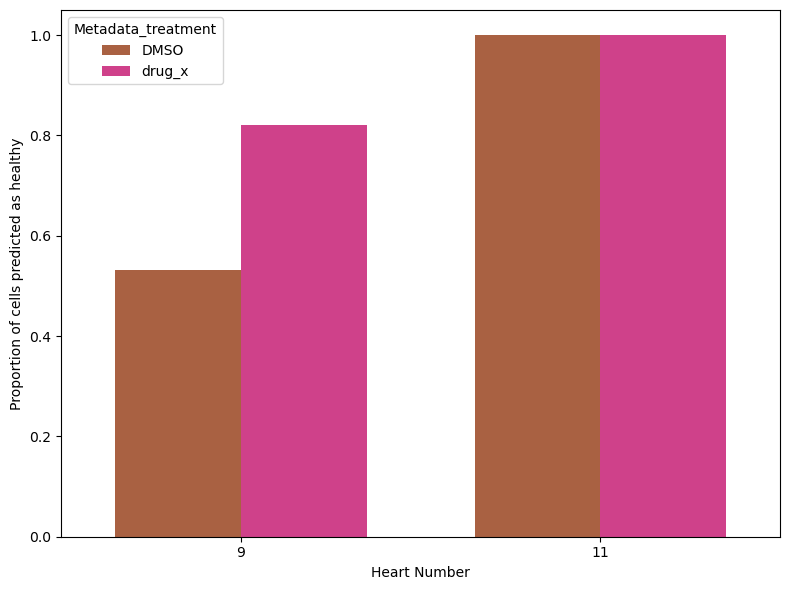

In [6]:
# Drop the "TGFRi" treatment
proportion_healthy = proportion_healthy[
    proportion_healthy["Metadata_treatment"] != "TGFRi"
]

# Define a custom palette for treatments
custom_palette = {
    "DMSO": "#BA5A31",
    "drug_x": "#E7298A",
}


# Plot the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(
    data=proportion_healthy,
    x="Metadata_heart_number",
    y="proportion_healthy",
    hue="Metadata_treatment",
    palette=custom_palette,
    dodge=True,
    width=0.7,
)

# Add axis labels
plt.xlabel("Heart Number")
plt.ylabel("Proportion of cells predicted as healthy")
plt.tight_layout()

# Save figure as png and pdf
plt.savefig(
    f"{fig_dir}/predicted_healthy_proportion_per_heart_number.pdf",
    bbox_inches="tight",
)
plt.savefig(
    f"{fig_dir}/predicted_healthy_proportion_per_heart_number.png",
    bbox_inches="tight",
)

plt.show()